# Parameter estimation for translational protein sector

This notebook was used to estimate the parameters for the translational protein sector as used in the revised proteome allocation model. This notebook has been created to establish the parameters for Cornyebacterium glutanicum ATCC 13032. Experimental measurements were performed by Lorenzo Wormer at the Karlsruhe Institute of Technology.

### Author: Samira L. van den Bogaard
## Setting up the notebook environment¶

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if os.path.split(os.getcwd())[1] == 'i1_preprocessing':
    os.chdir('../..')
    
from PAModelpy import Config

from Scripts.pam_generation_uniprot_id import setup_pputida_pam 
from Modules.utils.sector_config_functions import (perform_linear_regression,
                                                                        reset_translational_sector,
                                                                        plot_translational_protein_vs_mu,
                                                                        get_model_simulations_vs_sector,
                                                  )

Loading PAModelpy modules version 0.0.4.6
Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-06


In [2]:
DATA_FILE_PATH = os.path.join('Data', 'Cglutanicum_phenotypes', 
                              'cgl-proteome-quant-abs.xlsx')
FUNCTIONAL_ANNOTATION_FILE_PATH =os.path.join('Data', 'Cglutanicum_phenotypes', 
                                              'uniprotkb_taxonomy_id_196627_2025_01_30.xlsx')
PAM_DATA_FILE_PATH = os.path.join('Results', '1_preprocessing', 'proteinAllocationModel_iCGB21FR_EnzymaticData_250210.xlsx')
METADATA_FILE_PATH = os.path.join('Data', 'Cglutanicum_phenotypes', 'growth-rates.csv')
RESULT_FIG_PATH = os.path.join('Results', '1_preprocessing',
                               'figures', 'SuppFig_translational_sector_cglutanicum.png')

MEASURED_PROTEIN_FRACTION = 1
# MEASURED_PROTEIN_FRACTION = 0.55*0.55#0.55 * 0.55 #measured proteome vs g_p/gcdw in Ecoli

GLC_UPTAKE_RXN_ID = 'EX_glc__D_e'
BIOMASS_RXN_ID = 'Growth'
MW_GLC = 180.15588 #g/mol

## Get the proteomics data and map it to biological process annotation
### First get the proteomics data
We are only selecting group A-D because the other measurements are related to stress conditions, or alternative carbon sources. The medium and carbon source are different between A-D, which will result in a variety of growth rates

| Group | Group Desc                 | Condition                |
|-------|----------------------------|--------------------------|
| A     | Glu 4 %                    | A: Glu 4 %              |
| B     | Medium / LB                 | B: Medium / LB          |
| C     | Medium / BHI                | C: Medium / BHI         |
| D     | Substrate / Glu 8 %         | D: Substrate / Glu 8 %  |
| E     | Substrate / Glu + Ac        | E: Substrate / Glu + Ac |
| F     | Substrate / Ac 2 %          | F: Substrate / Ac 2 %   |
| G     | Stress / EtOH 2 %           | G: Stress / EtOH 2 %    |
| H     | Stress / H2O2               | H: Stress / H2O2        |
| I     | Stress / 37 °C              | I: Stress / 37 °C       |
| J     | Stress / pH 6.5             | J: Stress / pH 6.5      |
| K     | Stress / pH 7.9             | K: Stress / pH 7.9      |
| L     | Stress / NaCl 3 %           | L: Stress / NaCl 3 %    |


In [42]:
#get the validation data
df_proteomics = pd.read_excel(DATA_FILE_PATH)
#filter out the stress conditions
df_proteomics = df_proteomics[df_proteomics['condition'].str.contains(r'^[A-D]$', case=False, na=False)]
df_proteomics

,condition,replicate,gene,uniprot_accession,protein_desc,LFQ_intensity,abs_conc (mg / g_CDW)
0,A,3,Cgl0003,Q8NUD6,Beta sliding clamp,0.000946,0.278940
1,A,3,Cgl0009,Q8NUD0,Uncharacterized protein,0.000516,0.152161
2,A,3,Cgl0032,Q8NUA7,"ABC-type transporter, ATPase component",0.000455,0.134153
3,A,3,Cgl0033,Q8NUA6,Late embryogenesis abundant protein,0.000499,0.147116
4,A,3,Cgl0034,Q8NUA5,Peptidyl-prolyl cis-trans isomerase,0.005488,1.618670
...,...,...,...,...,...,...,...
4726,D,3,vdh,Q8NMB0,Vanillin dehydrogenase,0.000717,0.447926
4727,D,3,whiA,Q8NQ58,Probable cell division protein WhiA,0.000186,0.116293
4728,D,3,xseA,Q8NRM3,Exodeoxyribonuclease 7 large subunit,0.000112,0.069987
4729,D,3,ychF,Q8NRL6,Ribosome-binding ATPase YchF,0.000725,0.452690


### Get the functional annotation

In [43]:
#map the proteomics data to the functional annotation
funct_annotation = pd.read_excel(FUNCTIONAL_ANNOTATION_FILE_PATH)[['Entry', 'Gene Ontology (biological process)']]
funct_annotation

/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Entry,Gene Ontology (biological process)
0,P04964,diaminopimelate biosynthetic process [GO:00198...
1,P26512,diaminopimelate biosynthetic process [GO:00198...
2,P42449,glyoxylate cycle [GO:0006097]; tricarboxylic a...
3,P42450,glyoxylate catabolic process [GO:0009436]; gly...
4,P42455,L-leucine biosynthetic process [GO:0009098]
...,...,...
3093,Q8NUD2,NaN
3094,Q8NUD4,NaN
3095,Q8NUD7,NaN
3096,Q99340,NaN


### merge the proteomics information with the functional annotation

In [44]:
proteomics_annotated = pd.merge(df_proteomics, funct_annotation,
                               left_on = 'uniprot_accession', right_on = 'Entry').drop(['Entry', 'protein_desc'], axis =1)
proteomics_annotated 

,condition,replicate,gene,uniprot_accession,LFQ_intensity,abs_conc (mg / g_CDW),Gene Ontology (biological process)
0,A,3,Cgl0003,Q8NUD6,0.000946,0.278940,DNA strand elongation involved in DNA replicat...
1,B,3,Cgl0003,Q8NUD6,0.000748,0.359018,DNA strand elongation involved in DNA replicat...
2,C,2,Cgl0003,Q8NUD6,0.000758,0.375635,DNA strand elongation involved in DNA replicat...
3,C,3,Cgl0003,Q8NUD6,0.000763,0.385043,DNA strand elongation involved in DNA replicat...
4,D,3,Cgl0003,Q8NUD6,0.000567,0.353886,DNA strand elongation involved in DNA replicat...
...,...,...,...,...,...,...,...
4721,D,3,ectP,Q79VE0,0.000174,0.108871,amino acid transport [GO:0006865]; nitrogen co...
4722,D,3,miaB,Q8NP67,0.000266,0.166165,tRNA methylthiolation [GO:0035600]
4723,D,3,mnmA,Q8NR24,0.000067,0.041885,tRNA wobble position uridine thiolation [GO:00...
4724,D,3,prpB2,Q8NSL2,0.000416,0.259569,"propionate catabolic process, 2-methylcitrate ..."


## Find those proteins which are included in the translational protein sector

In [45]:
def is_related_to_translation(go_annotation: str):
    if not isinstance(go_annotation, str): return False
    return (('[GO:0006412]' in go_annotation) or ('[GO:0002181]' in go_annotation))

proteomics_translation = proteomics_annotated.copy()
proteomics_translation['translational_sector'] = proteomics_translation[
    'Gene Ontology (biological process)'
].apply(lambda go: is_related_to_translation(go))

proteomics_translation

,condition,replicate,gene,uniprot_accession,LFQ_intensity,abs_conc (mg / g_CDW),Gene Ontology (biological process),translational_sector
0,A,3,Cgl0003,Q8NUD6,0.000946,0.278940,DNA strand elongation involved in DNA replicat...,False
1,B,3,Cgl0003,Q8NUD6,0.000748,0.359018,DNA strand elongation involved in DNA replicat...,False
2,C,2,Cgl0003,Q8NUD6,0.000758,0.375635,DNA strand elongation involved in DNA replicat...,False
3,C,3,Cgl0003,Q8NUD6,0.000763,0.385043,DNA strand elongation involved in DNA replicat...,False
4,D,3,Cgl0003,Q8NUD6,0.000567,0.353886,DNA strand elongation involved in DNA replicat...,False
...,...,...,...,...,...,...,...,...
4721,D,3,ectP,Q79VE0,0.000174,0.108871,amino acid transport [GO:0006865]; nitrogen co...,False
4722,D,3,miaB,Q8NP67,0.000266,0.166165,tRNA methylthiolation [GO:0035600],False
4723,D,3,mnmA,Q8NR24,0.000067,0.041885,tRNA wobble position uridine thiolation [GO:00...,False
4724,D,3,prpB2,Q8NSL2,0.000416,0.259569,"propionate catabolic process, 2-methylcitrate ...",False


## Get the growth rates for the conditions

In [46]:
growth_rates_per_condition = pd.read_csv(METADATA_FILE_PATH)
growth_rates_per_condition

,condition,mu,stderr,rsquared,desc
0,A,0.470758,0.038449,0.993373,Glu 4 %
1,B,0.365737,0.013433,0.998653,Medium / LB
2,C,0.420190,0.016385,0.998482,Medium / BHI
3,D,0.450025,0.063295,0.980602,Substrate / Glu 8 %
4,E,0.258879,0.114236,0.837016,Substrate / Glu + Ac
5,F,0.243610,0.011023,0.997957,Substrate / Ac 2 %
6,G,0.173229,0.012408,0.994896,Stress / EtOH 2 %
7,H,0.336233,0.010768,0.998976,Stress / H2O2
8,I,0.247492,0.006863,0.999232,Stress / 37 °C
9,J,0.326897,0.006356,0.999622,Stress / pH 6.5


In [47]:
proteomics_translation_with_mu = pd.merge(proteomics_translation, growth_rates_per_condition[['condition', 'mu']],
                                         on = 'condition')
proteomics_translation_with_mu

,condition,replicate,gene,uniprot_accession,LFQ_intensity,abs_conc (mg / g_CDW),Gene Ontology (biological process),translational_sector,mu
0,A,3,Cgl0003,Q8NUD6,0.000946,0.278940,DNA strand elongation involved in DNA replicat...,False,0.470758
1,A,3,Cgl0009,Q8NUD0,0.000516,0.152161,NaN,False,0.470758
2,A,3,Cgl0032,Q8NUA7,0.000455,0.134153,NaN,False,0.470758
3,A,3,Cgl0033,Q8NUA6,0.000499,0.147116,NaN,False,0.470758
4,A,3,Cgl0034,Q8NUA5,0.005488,1.618670,protein folding [GO:0006457]; protein peptidyl...,False,0.470758
...,...,...,...,...,...,...,...,...,...
4721,D,3,ectP,Q79VE0,0.000174,0.108871,amino acid transport [GO:0006865]; nitrogen co...,False,0.450025
4722,D,3,miaB,Q8NP67,0.000266,0.166165,tRNA methylthiolation [GO:0035600],False,0.450025
4723,D,3,mnmA,Q8NR24,0.000067,0.041885,tRNA wobble position uridine thiolation [GO:00...,False,0.450025
4724,D,3,prpB2,Q8NSL2,0.000416,0.259569,"propionate catabolic process, 2-methylcitrate ...",False,0.450025


## Calculate the fractions allocated to translational proteins per condition

In [48]:
proteome_conc_sum = proteomics_translation.groupby(['condition', 'translational_sector']).sum()[['LFQ_intensity']].reset_index()
translational_protein_per_cond = proteome_conc_sum[proteome_conc_sum.translational_sector].merge(
    growth_rates_per_condition[['condition', 'mu']],
    on = 'condition').drop('translational_sector', axis=1)

translational_protein_per_cond = translational_protein_per_cond.sort_values('mu')

translational_protein_per_cond

/tmp/ipykernel_390306/1222432811.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  proteome_conc_sum = proteomics_translation.groupby(['condition', 'translational_sector']).sum()[['LFQ_intensity']].reset_index()


,condition,LFQ_intensity,mu
1,B,0.181854,0.365737
2,C,0.369830,0.420190
3,D,0.218651,0.450025
0,A,0.194084,0.470758


Text(0.5, 0, 'growth rate (h-1)')

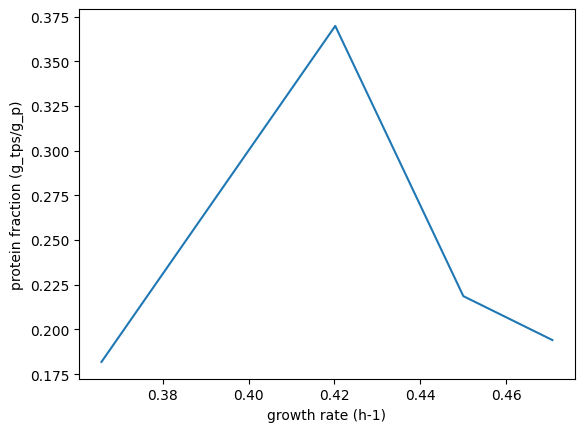

In [49]:
plt.plot(translational_protein_per_cond.mu, translational_protein_per_cond.LFQ_intensity)
plt.ylabel('protein fraction (g_tps/g_p)')
plt.xlabel('growth rate (h-1)')